# Agentic AI Fundamentals

## Notebook 13: Production Agent Architecture and Capstone

This capstone assembles the course into one small but production-minded support agent. The system retrieves policy evidence, proposes a typed action, applies an execution policy, pauses for human approval, invokes an idempotent MCP tool, persists graph checkpoints, and emits a structured trace.

The goal is not to imitate an entire enterprise platform inside a notebook. It is to make the important boundaries visible: model versus runtime, evidence versus instruction, proposal versus authorization, and successful output versus reliable operation.

## Learning objectives

By the end of this notebook, you should be able to:

- organize an agent as explicit architectural layers;
- combine retrieval, planning, policy, approval, and execution;
- expose business capabilities through MCP without trusting them automatically;
- persist LangGraph checkpoints in SQLite;
- make side effects idempotent;
- resume an interrupted run with the same thread identity;
- collect a useful operational trace;
- evaluate both successful and rejected paths; and
- replace deterministic planning with Gemini while preserving runtime controls.

## 1. Reference architecture

                    ┌───────────────────┐
                    │   User request    │
                    └─────────┬─────────┘
                              │
                              ▼
                    ┌───────────────────┐
                    │ Intake validation │
                    └─────────┬─────────┘        
                              │                  ┌─────────────┐
                              ├──── events ────► │ Trace store │
                              │                  └─────────────┘
                              │                  
                              ▼
                    ┌───────────────────┐
                    │ Policy retrieval  │
                    └─────────┬─────────┘
                              │
                              ▼
                    ┌───────────────────┐
                    │  Action proposal  │
                    └─────────┬─────────┘
                              │                  ┌───────────────┐  
                              ├──── state ─────► │ Checkpoint DB │
                              │                  └───────────────┘
                              │                  
                              ▼
                    ┌───────────────────┐
                    │    Policy gate    │
                    └─────────┬─────────┘
                              │
              ┌───────────────┼────────────────┐
              │               │                │
              ▼               ▼                ▼
         Read only       Side effect         Denied
              │               │                │
              ▼               ▼                │
    ┌─────────────────┐ ┌─────────────────┐    │
    │  MCP execution  │ │ Human approval  │    │
    └────────┬────────┘ └────────┬────────┘    │
             │                   │             │    ┌───────────────┐
             │                   ├──── state ──┼──► │ Checkpoint DB │
             │                   │             │    └───────────────┘
             │                   │             │    
             │                   ▼             │
             │          ┌─────────────────┐    │
             │          │  MCP execution  │    │
             │          └────────┬────────┘    │
             │                   │             │
             └─────────┬─────────┘             │
                       │                       │
                       ├───────────────────────┘
                       │
                       ▼
              ┌─────────────────┐
              │ Final response  │
              └─────────────────┘



The planner may be probabilistic; the authorization and execution boundaries are ordinary application code. A model can propose a refund case, but it cannot approve its own proposal or bypass the MCP allowlist.

## 2. Production concerns and notebook implementations

| Concern | Capstone implementation | Production extension |
|---|---|---|
| Input contract | Pydantic validation | Authentication and tenant context |
| Grounding | Small local policy corpus | Versioned vector/search service |
| Planning | Deterministic baseline or Gemini | Provider adapter and fallbacks |
| Authorization | Explicit tool policy | RBAC/ABAC policy service |
| Approval | LangGraph interrupt | Durable approval UI and identity |
| Integration | In-process MCP server | Authenticated remote MCP server |
| Side effects | SQLite idempotency record | Transactional business service |
| Persistence | SQLite checkpointer | Managed durable database |
| Observability | Structured state trace | OpenTelemetry and centralized logs |
| Evaluation | Scenario assertions | CI suite, holdout set, online monitoring |

## 3. Install dependencies

Everything remains inside Colab. The checkpoint package is separate from core LangGraph, and the MCP major version is pinned because this course uses the stable v2 API.

In [1]:
%pip install -q -U "langgraph>=1.2,<2" "langgraph-checkpoint-sqlite>=3,<4" "mcp>=2,<3" "google-genai>=1.0.0" "pydantic>=2.7,<3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.1 which is incompatible.


In [2]:
import hashlib
import json
import operator
import re
import sqlite3
import time
from pathlib import Path
from typing import Annotated, Any, Literal, TypedDict

import aiosqlite
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from mcp import Client as MCPClient
from mcp.server import MCPServer
from pydantic import BaseModel, ConfigDict, Field, ValidationError

## 4. Create durable local storage

We use two SQLite databases because they have different responsibilities:

- the **business database** records refund cases and enforces idempotency;
- the **checkpoint database** stores LangGraph execution state.

Keeping them conceptually separate matters. Replaying graph state must never duplicate a business action.

In [3]:
RUNTIME_DIRECTORY = Path("/content") if Path("/content").exists() else Path.cwd()
BUSINESS_DB_PATH = RUNTIME_DIRECTORY / "capstone_business.sqlite"
CHECKPOINT_DB_PATH = RUNTIME_DIRECTORY / "capstone_checkpoints.sqlite"


business_db = sqlite3.connect(BUSINESS_DB_PATH, check_same_thread=False)
business_db.row_factory = sqlite3.Row
business_db.execute(
    '''
    CREATE TABLE IF NOT EXISTS refund_cases (
        case_id TEXT PRIMARY KEY,
        order_id TEXT NOT NULL,
        reason TEXT NOT NULL,
        idempotency_key TEXT NOT NULL UNIQUE,
        created_at REAL NOT NULL
    )
    '''
)
business_db.commit()


checkpoint_connection = await aiosqlite.connect(CHECKPOINT_DB_PATH)
checkpointer = AsyncSqliteSaver(checkpoint_connection)

The files survive ordinary notebook-cell execution, although a Colab runtime itself is still temporary. A deployed service would use durable managed storage and migrations rather than creating tables during import.

## 5. Define the business capability as an MCP tool

The function derives a stable case identifier from the idempotency key. Calling it twice with the same key returns the same case rather than creating duplicate refunds.

In [4]:
support_server = MCPServer(
    name="support-operations",
    title="Support Operations",
    description="Controlled support capabilities for the capstone agent.",
    version="1.0.0",
)


@support_server.tool()
def create_refund_case(
    order_id: str,
    reason: str,
    idempotency_key: str,
) -> dict[str, Any]:
    '''Create one reviewable refund case without duplicating retries.'''
    if not re.fullmatch(r"ORD-[0-9]{4}", order_id):
        raise ValueError("order_id must match ORD-0000")
    if not 5 <= len(reason) <= 300:
        raise ValueError("reason must contain 5 to 300 characters")
    if not 12 <= len(idempotency_key) <= 80:
        raise ValueError("idempotency_key must contain 12 to 80 characters")

    existing = business_db.execute(
        "SELECT * FROM refund_cases WHERE idempotency_key = ?",
        (idempotency_key,),
    ).fetchone()
    if existing:
        return {**dict(existing), "duplicate_prevented": True}

    case_id = "RF-" + hashlib.sha256(
        idempotency_key.encode("utf-8")
    ).hexdigest()[:10].upper()
    created_at = time.time()
    business_db.execute(
        '''
        INSERT INTO refund_cases
            (case_id, order_id, reason, idempotency_key, created_at)
        VALUES (?, ?, ?, ?, ?)
        ''',
        (case_id, order_id, reason, idempotency_key, created_at),
    )
    business_db.commit()
    return {
        "case_id": case_id,
        "order_id": order_id,
        "reason": reason,
        "idempotency_key": idempotency_key,
        "created_at": created_at,
        "duplicate_prevented": False,
    }

In [5]:
async def discover_support_tools() -> list[dict[str, Any]]:
    async with MCPClient(support_server) as client:
        result = await client.list_tools()
        return [tool.model_dump() for tool in result.tools]


discovered_support_tools = await discover_support_tools()
print(json.dumps(discovered_support_tools, indent=2))

[
  {
    "name": "create_refund_case",
    "title": null,
    "description": "Create one reviewable refund case without duplicating retries.",
    "input_schema": {
      "type": "object",
      "properties": {
        "order_id": {
          "title": "Order Id",
          "type": "string"
        },
        "reason": {
          "title": "Reason",
          "type": "string"
        },
        "idempotency_key": {
          "title": "Idempotency Key",
          "type": "string"
        }
      },
      "required": [
        "order_id",
        "reason",
        "idempotency_key"
      ],
      "title": "create_refund_caseArguments"
    },
    "execution": null,
    "output_schema": {
      "additionalProperties": true,
      "title": "create_refund_caseDictOutput",
      "type": "object"
    },
    "icons": null,
    "annotations": null,
    "meta": null
  }
]


Discovery gives the host a schema, not permission. The host will apply its own allowlist and require approval because this tool causes a business side effect.

## 6. Create the retrieval layer

The corpus is deliberately small so we can inspect every result. Each document carries a stable source identifier. The response layer must preserve those identifiers rather than presenting retrieved text as unattributed model knowledge.

In [6]:
POLICY_DOCUMENTS = [
    {
        "source_id": "refund-policy-v3",
        "text": (
            "Refund requests may be opened within 30 days of delivery. "
            "Creating a case does not guarantee approval."
        ),
    },
    {
        "source_id": "approval-policy-v2",
        "text": (
            "Any tool that creates or changes a business record requires "
            "explicit human approval before execution."
        ),
    },
    {
        "source_id": "privacy-policy-v1",
        "text": (
            "Responses must not expose internal identifiers other than the "
            "case identifier intended for the customer."
        ),
    },
]


def tokenize(text: str) -> set[str]:
    return set(re.findall(r"[a-z0-9]+", text.lower()))


def retrieve_policy(query: str, limit: int = 2) -> list[dict[str, Any]]:
    query_terms = tokenize(query)
    scored = []
    for document in POLICY_DOCUMENTS:
        score = len(query_terms & tokenize(document["text"]))
        if score:
            scored.append((score, document))
    scored.sort(key=lambda item: (-item[0], item[1]["source_id"]))
    return [
        {**document, "score": score}
        for score, document in scored[:limit]
    ]

## 7. Define typed input, plan, policy, and state contracts

`ActionPlan` is a proposal, not an authorization token. The policy node will independently verify its tool name and arguments.

In [7]:
class UserRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")
    user_id: str = Field(pattern=r"^[a-zA-Z0-9_-]{3,40}$")
    message: str = Field(min_length=3, max_length=2_000)


class ActionPlan(BaseModel):
    model_config = ConfigDict(extra="forbid")
    intent: Literal["answer_policy", "create_refund_case", "unsupported"]
    tool_name: Literal["create_refund_case"] | None = None
    arguments: dict[str, Any] = Field(default_factory=dict)
    rationale: str = Field(min_length=3, max_length=500)


class PolicyDecision(BaseModel):
    decision: Literal["allow", "require_approval", "deny"]
    reason: str


class AgentState(TypedDict, total=False):
    request: dict[str, Any]
    evidence: list[dict[str, Any]]
    plan: dict[str, Any]
    policy: dict[str, Any]
    approved: bool
    observation: dict[str, Any]
    final_answer: str
    status: str
    trace: Annotated[list[dict[str, Any]], operator.add]

## 8. Implement deterministic planning first

A deterministic planner gives us a stable baseline and allows the entire capstone to run without an API key. The optional Gemini planner later produces the same `ActionPlan` contract.

In [8]:
PLANNER_MODE = "deterministic"
gemini_client = None
MODEL_NAME = "gemini-3.8-flash"


def stable_idempotency_key(user_id: str, order_id: str, message: str) -> str:
    material = f"{user_id}|{order_id}|{message.strip().lower()}"
    return hashlib.sha256(material.encode("utf-8")).hexdigest()[:32]


def deterministic_plan(request: UserRequest) -> ActionPlan:
    order_match = re.search(r"ORD-[0-9]{4}", request.message, re.IGNORECASE)
    asks_for_refund = "refund" in request.message.lower() and order_match is not None

    if asks_for_refund:
        order_id = order_match.group(0).upper()
        return ActionPlan(
            intent="create_refund_case",
            tool_name="create_refund_case",
            arguments={
                "order_id": order_id,
                "reason": request.message,
                "idempotency_key": stable_idempotency_key(
                    request.user_id, order_id, request.message
                ),
            },
            rationale="The user explicitly requested a refund case for a valid order ID.",
        )

    if "refund" in request.message.lower():
        return ActionPlan(
            intent="answer_policy",
            rationale="The request asks about refund policy without requesting an executable action.",
        )

    return ActionPlan(
        intent="unsupported",
        rationale="The request is outside this agent's refund-support scope.",
    )

## 9. Implement graph nodes

Each node returns only its state updates and one or more structured trace events. The `trace` reducer appends events safely across transitions.

In [9]:
def event(name: str, **data: Any) -> list[dict[str, Any]]:
    return [{"event": name, "timestamp": time.time(), **data}]


def intake_node(state: AgentState) -> dict[str, Any]:
    try:
        validated = UserRequest.model_validate(state["request"])
        return {
            "request": validated.model_dump(),
            "status": "running",
            "trace": event("input_validated", user_id=validated.user_id),
        }
    except ValidationError as error:
        return {
            "status": "invalid_input",
            "final_answer": "The request did not satisfy the input contract.",
            "trace": event("input_rejected", errors=error.errors()),
        }


def retrieval_node(state: AgentState) -> dict[str, Any]:
    evidence = retrieve_policy(state["request"]["message"])
    return {
        "evidence": evidence,
        "trace": event(
            "retrieval_completed",
            source_ids=[item["source_id"] for item in evidence],
        ),
    }

In [24]:
async def planning_node(state: AgentState) -> dict[str, Any]:
    request = UserRequest.model_validate(state["request"])

    if PLANNER_MODE == "gemini":
        if gemini_client is None:
            raise RuntimeError("Gemini client has not been configured.")
        from google.genai import types

        planning_context = {
            "user_request": request.model_dump(),
            "retrieved_evidence": state.get("evidence", []),
            "available_tools": [
                {
                    "name": tool["name"],
                    "description": tool.get("description"),
                    "input_schema": tool["input_schema"],
                }
                for tool in discovered_support_tools
            ],
        }
        response = await gemini_client.aio.models.generate_content(
            model=MODEL_NAME,
            contents=json.dumps(planning_context),
            config=types.GenerateContentConfig(
                system_instruction=(
                    "Propose an action for the support runtime. Never approve your "
                    "own action. Use create_refund_case only when the user explicitly "
                    "requests a refund and supplies an ORD-0000 identifier. Do not "
                    "invent an idempotency key."
                ),
                response_mime_type="application/json",
                # Use an explicit Gemini-compatible JSON schema here.
                # ActionPlan.model_json_schema() contains additionalProperties
                # (from dict[str, Any] and extra="forbid"), which the Gemini
                # Developer API rejects. We still validate the returned JSON
                # with the stricter Pydantic ActionPlan model below.
                response_json_schema={
                    "type": "object",
                    "properties": {
                        "intent": {
                            "type": "string",
                            "enum": [
                                "answer_policy",
                                "create_refund_case",
                                "unsupported",
                            ],
                        },
                        "tool_name": {
                            "anyOf": [
                                {"type": "string", "enum": ["create_refund_case"]},
                                {"type": "null"},
                            ]
                        },
                        "arguments": {
                            "type": "object",
                            "properties": {
                                "order_id": {"type": "string"}
                            },
                        },
                        "rationale": {"type": "string"},
                    },
                    "required": ["intent", "tool_name", "arguments", "rationale"],
                },
                temperature=0,
            ),
        )
        plan = ActionPlan.model_validate_json(response.text)

        if plan.tool_name == "create_refund_case":
            order_id = str(plan.arguments.get("order_id", "")).upper()
            plan.arguments["order_id"] = order_id
            plan.arguments["reason"] = request.message
            plan.arguments["idempotency_key"] = stable_idempotency_key(
                request.user_id, order_id, request.message
            )
    else:
        plan = deterministic_plan(request)

    return {
        "plan": plan.model_dump(),
        "trace": event(
            "plan_created",
            planner=PLANNER_MODE,
            intent=plan.intent,
            tool_name=plan.tool_name,
        ),
    }

In [25]:
ALLOWED_TOOLS = {"create_refund_case"}


def policy_node(state: AgentState) -> dict[str, Any]:
    plan = ActionPlan.model_validate(state["plan"])

    if plan.intent == "unsupported":
        decision = PolicyDecision(
            decision="deny",
            reason="The request is outside the configured support scope.",
        )
    elif plan.tool_name is None:
        decision = PolicyDecision(
            decision="allow",
            reason="No external side effect was proposed.",
        )
    elif plan.tool_name not in ALLOWED_TOOLS:
        decision = PolicyDecision(
            decision="deny",
            reason="The proposed tool is not allowlisted.",
        )
    elif not re.fullmatch(
        r"ORD-[0-9]{4}", str(plan.arguments.get("order_id", ""))
    ):
        decision = PolicyDecision(
            decision="deny",
            reason="The proposed order ID is invalid.",
        )
    else:
        decision = PolicyDecision(
            decision="require_approval",
            reason="Creating a refund case changes business state.",
        )

    return {
        "policy": decision.model_dump(),
        "trace": event("policy_decided", **decision.model_dump()),
    }


def approval_node(state: AgentState) -> dict[str, Any]:
    plan = ActionPlan.model_validate(state["plan"])
    approved = interrupt({
        "question": "Approve creation of this refund case?",
        "tool_name": plan.tool_name,
        "arguments": {
            "order_id": plan.arguments.get("order_id"),
            "reason": plan.arguments.get("reason"),
        },
        "policy_reason": state["policy"]["reason"],
    })
    return {
        "approved": bool(approved),
        "trace": event("human_decision", approved=bool(approved)),
    }

In [26]:
async def execution_node(state: AgentState) -> dict[str, Any]:
    plan = ActionPlan.model_validate(state["plan"])
    if plan.tool_name not in ALLOWED_TOOLS:
        raise PermissionError("Execution attempted for a non-allowlisted tool.")

    async with MCPClient(support_server, raise_exceptions=False) as client:
        result = await client.call_tool(plan.tool_name, plan.arguments)

    observation = {
        "success": not result.is_error,
        "tool_name": plan.tool_name,
        "data": result.structured_content,
        "error": result.content[0].text if result.is_error else None,
    }
    return {
        "observation": observation,
        "status": "executed" if observation["success"] else "tool_failed",
        "trace": event(
            "tool_executed",
            tool_name=plan.tool_name,
            success=observation["success"],
        ),
    }


def response_node(state: AgentState) -> dict[str, Any]:
    status = state.get("status")
    policy = state.get("policy", {}).get("decision")
    evidence = state.get("evidence", [])
    sources = [item["source_id"] for item in evidence]

    if status == "invalid_input":
        answer = state["final_answer"]
    elif state.get("approved") is False:
        answer = "The refund case was not created because approval was declined."
    elif policy == "deny":
        answer = "I cannot perform that request with the available permissions."
    elif state.get("observation", {}).get("success"):
        tool_data = state["observation"]["data"]
        case = tool_data.get("result", tool_data)
        answer = (
            f"Refund case {case['case_id']} was created for {case['order_id']}. "
            "Creation does not guarantee refund approval."
        )
    else:
        policy_text = " ".join(item["text"] for item in evidence)
        answer = policy_text or "I could not find relevant policy information."

    if sources and policy != "deny":
        answer += f" Sources: {', '.join(sources)}."

    return {
        "final_answer": answer,
        "status": "completed",
        "trace": event("response_created", source_ids=sources),
    }

## 10. Assemble and compile the graph

Invalid input exits early. Read-only policy questions go directly to the response. Side effects pause for approval. Rejection and denial share the response layer but remain distinguishable in state and trace.

In [27]:
def route_after_intake(state: AgentState) -> str:
    return "respond" if state.get("status") == "invalid_input" else "retrieve"


def route_after_policy(state: AgentState) -> str:
    decision = state["policy"]["decision"]
    if decision == "deny" or state["plan"]["tool_name"] is None:
        return "respond"
    if decision == "require_approval":
        return "approval"
    return "execute"


def route_after_approval(state: AgentState) -> str:
    return "execute" if state.get("approved") else "respond"


builder = StateGraph(AgentState)
builder.add_node("intake", intake_node)
builder.add_node("retrieve", retrieval_node)
builder.add_node("plan", planning_node)
builder.add_node("policy", policy_node)
builder.add_node("approval", approval_node)
builder.add_node("execute", execution_node)
builder.add_node("respond", response_node)

builder.add_edge(START, "intake")
builder.add_conditional_edges(
    "intake", route_after_intake, {"retrieve": "retrieve", "respond": "respond"}
)
builder.add_edge("retrieve", "plan")
builder.add_edge("plan", "policy")
builder.add_conditional_edges(
    "policy",
    route_after_policy,
    {"respond": "respond", "approval": "approval", "execute": "execute"},
)
builder.add_conditional_edges(
    "approval", route_after_approval, {"execute": "execute", "respond": "respond"}
)
builder.add_edge("execute", "respond")
builder.add_edge("respond", END)

support_agent = builder.compile(checkpointer=checkpointer)

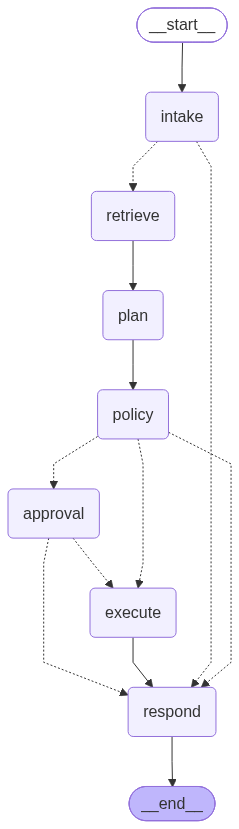

In [28]:
from IPython.display import Image, display

display(
    Image(
        support_agent.get_graph().draw_mermaid_png()
    )
)

## 11. Run the read-only path

Every run receives a stable `thread_id`. LangGraph uses it to associate invocations with the correct persisted checkpoint history.

In [29]:
read_config = {"configurable": {"thread_id": "capstone-read-001"}}
read_result = await support_agent.ainvoke(
    {
        "request": {
            "user_id": "user_17",
            "message": "What is the refund policy?",
        },
        "trace": [],
    },
    config=read_config,
)

print(read_result["final_answer"])
print(json.dumps(read_result["trace"], indent=2))

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

## 12. Pause a side effect for approval

The graph stops before the MCP tool executes. The checkpoint contains the proposed action and retrieved evidence, while the business database remains unchanged.

In [30]:
action_config = {"configurable": {"thread_id": "capstone-action-001"}}
paused_result = await support_agent.ainvoke(
    {
        "request": {
            "user_id": "user_17",
            "message": "Please request a refund for ORD-1001 because it arrived damaged.",
        },
        "trace": [],
    },
    config=action_config,
)

print(paused_result["__interrupt__"])
rows_before_approval = business_db.execute(
    "SELECT COUNT(*) AS count FROM refund_cases"
).fetchone()["count"]
print("Refund cases before approval:", rows_before_approval)

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [ ]:
saved_state = await support_agent.aget_state(action_config)
print("Next node:", saved_state.next)
print("Saved intent:", saved_state.values["plan"]["intent"])
print("Saved policy:", saved_state.values["policy"])

## 13. Resume with approval

`Command(resume=True)` continues the same thread. The approval node restarts from its beginning, so no side effect should occur before `interrupt()`. Our execution is in a separate downstream node.

In [ ]:
approved_result = await support_agent.ainvoke(
    Command(resume=True),
    config=action_config,
)

print(approved_result["final_answer"])
print(json.dumps(approved_result["trace"], indent=2))

## 14. Verify idempotency independently

Checkpointing and idempotency solve different problems. We now call the MCP tool again with the exact same arguments. The graph need not do this during normal operation; the test proves that an accidental retry cannot duplicate the business action.

In [ ]:
async def replay_same_tool_call(arguments: dict[str, Any]) -> dict[str, Any]:
    async with MCPClient(support_server) as client:
        result = await client.call_tool("create_refund_case", arguments)
        return result.structured_content


replay_result = await replay_same_tool_call(approved_result["plan"]["arguments"])
replay_case = replay_result.get("result", replay_result)
print(replay_case)
assert replay_case["duplicate_prevented"] is True

## 15. Exercise the rejection path

A rejection is a successful safety outcome, not an infrastructure failure. The run completes with no tool observation and no new business record.

In [ ]:
reject_config = {"configurable": {"thread_id": "capstone-reject-001"}}
rejected_pause = await support_agent.ainvoke(
    {
        "request": {
            "user_id": "user_18",
            "message": "Request a refund for ORD-1002 because the item was incorrect.",
        },
        "trace": [],
    },
    config=reject_config,
)
rejected_result = await support_agent.ainvoke(
    Command(resume=False),
    config=reject_config,
)

print(rejected_result["final_answer"])
print("Tool executed:", "observation" in rejected_result)

## 16. Evaluate the complete system

The checks cover outcomes and trajectories. We verify sources, approval, execution, persistence, idempotency, and rejection—not merely whether the final sentence sounds reasonable.

In [31]:
def trace_events(state: AgentState) -> list[str]:
    return [item["event"] for item in state.get("trace", [])]


capstone_checks = {
    "read_path_completed": read_result["status"] == "completed",
    "read_path_grounded": "refund-policy-v3" in read_result["final_answer"],
    "approval_was_requested": bool(paused_result.get("__interrupt__")),
    "approved_tool_succeeded": approved_result["observation"]["success"],
    "approved_trace_has_human_decision": (
        "human_decision" in trace_events(approved_result)
    ),
    "checkpoint_reached_approval": saved_state.next == ("approval",),
    "idempotency_prevented_duplicate": replay_case["duplicate_prevented"],
    "rejection_skipped_execution": "observation" not in rejected_result,
    "rejection_completed": rejected_result["status"] == "completed",
}

print(json.dumps(capstone_checks, indent=2))
print("Overall pass:", all(capstone_checks.values()))

{
  "read_path_completed": true,
  "read_path_grounded": true,
  "approval_was_requested": true,
  "approved_tool_succeeded": true,
  "approved_trace_has_human_decision": true,
  "checkpoint_reached_approval": true,
  "idempotency_prevented_duplicate": true,
  "rejection_skipped_execution": true,
  "rejection_completed": true
}
Overall pass: True


## 17. Optional: enable the real Gemini planner

The graph already supports a Gemini planning branch. Enabling it changes only the proposal layer; retrieval, policy, approval, MCP execution, persistence, and response rules remain application-controlled.

Add `GEMINI_API_KEY` to Colab Secrets before running the next cells.

In [32]:
import os
from google import genai


def load_gemini_api_key() -> str:
    try:
        from google.colab import userdata
        api_key = userdata.get("GEMINI_API_KEY")
    except (ImportError, KeyError):
        api_key = os.getenv("GEMINI_API_KEY")

    if not api_key:
        raise RuntimeError("Add GEMINI_API_KEY to Colab Secrets.")
    return api_key


gemini_client = genai.Client(api_key=load_gemini_api_key())
PLANNER_MODE = "gemini"

In [33]:
live_config = {"configurable": {"thread_id": "capstone-gemini-001"}}
live_paused = await support_agent.ainvoke(
    {
        "request": {
            "user_id": "user_live",
            "message": "Please open a refund request for ORD-1003; the product is defective.",
        },
        "trace": [],
    },
    config=live_config,
)

print("Planner:", live_paused["trace"][-2].get("planner", "see trace"))
print("Plan:", json.dumps(live_paused["plan"], indent=2))
print("Interrupt:", live_paused["__interrupt__"])

Planner: gemini
Plan: {
  "intent": "create_refund_case",
  "tool_name": "create_refund_case",
  "arguments": {
    "order_id": "ORD-1003",
    "reason": "Please open a refund request for ORD-1003; the product is defective.",
    "idempotency_key": "78b9eeaf84aa2d1575a5e58bcb400f7a"
  },
  "rationale": "The user explicitly requested a refund for order ORD-1003."
}
Interrupt: [Interrupt(value={'question': 'Approve creation of this refund case?', 'tool_name': 'create_refund_case', 'arguments': {'order_id': 'ORD-1003', 'reason': 'Please open a refund request for ORD-1003; the product is defective.'}, 'policy_reason': 'Creating a refund case changes business state.'}, id='9b6bbedfe578696a6353604a7760aa77', response_schema=None)]


In [34]:
# Inspect the proposed action before choosing the resume value.
live_result = await support_agent.ainvoke(
    Command(resume=True),  # Change to False to reject it.
    config=live_config,
)
print(live_result["final_answer"])

Refund case RF-350A887A80 was created for ORD-1003. Creation does not guarantee refund approval. Sources: privacy-policy-v1, refund-policy-v3.


The model supplies `intent`, `tool_name`, arguments, and rationale under a validated schema. The host generates the idempotency key itself, because operational identifiers should not depend on model creativity.

## 18. What this notebook intentionally leaves out

A production deployment still needs:

- authenticated users, tenant isolation, and authorization claims;
- secrets management rather than notebook secrets;
- a remote durable database with migrations and backups;
- authenticated MCP transports and server identity verification;
- distributed tracing, metrics, alerts, and protected log retention;
- provider timeouts, retry budgets, circuit breakers, and fallbacks;
- concurrency tests and transactional guarantees;
- prompt-injection testing for retrieved content;
- offline evaluation in CI and monitored online quality metrics;
- privacy review, retention rules, and incident response procedures; and
- a real approval interface that records approver identity and decision time.

A notebook can demonstrate architecture, but production readiness is an operational property of the entire deployed system.

## 19. Capstone exercise

Extend the system with a read-only `get_refund_case(case_id)` MCP tool. Then:

1. add a new `lookup_refund_case` intent to `ActionPlan`;
2. allow it without human approval because it is read-only;
3. route it through the same MCP execution node;
4. redact the internal idempotency key from the final response;
5. add one success test and one unknown-case test; and
6. compare the traces of lookup and creation to prove that only creation pauses.

This exercise is intentionally not solved. It asks you to modify schemas, routing, policy, execution, response formatting, and evaluation—the full vertical slice of an agent feature.

In [ ]:
# Implement the read-only refund-case lookup vertical slice here.

## Course summary

Across the series, we moved from a language model call to a controlled agent runtime:

- structured outputs turned model text into validated data;
- tool registries separated proposals from execution;
- bounded loops introduced explicit termination;
- state and LangGraph made transitions inspectable;
- RAG grounded responses in retrieved evidence;
- guardrails and approval protected side effects;
- evaluation measured outcomes, trajectories, safety, cost, and latency;
- multi-agent patterns introduced delegation and ownership boundaries; and
- MCP standardized capability discovery and invocation.

The capstone brings those ideas together. A reliable agent is not just a strong model with a persuasive prompt. It is a software system with contracts, policy, persistence, observability, tests, and deliberately limited authority.

**Agentic AI Fundamentals is now complete: Notebooks 00–13.**